## Modelo Baseline - Diabetes

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-19

## 📚 Import  libraries

In [15]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import KFold, cross_validate

## 💾 Load data

In [11]:
MODEL_INPUT_DIR = Path("../../data/05_model_input")
train = pd.read_parquet(MODEL_INPUT_DIR / "train.parquet")
test = pd.read_parquet(MODEL_INPUT_DIR / "test.parquet")

COLUMNAS_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"

X_train, y_train = train[COLUMNAS_FEATURES], train[TARGET]
X_test, y_test = test[COLUMNAS_FEATURES], test[TARGET]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (629, 8) | Test: (158, 8)


## 👷 Data preparation

##  Decisiones

- Se reutiliza el split ya guardado en `data/05_model_input/` en vez de
  generar uno nuevo, para que los modelos de las Tareas 5, 6 y 7 sean comparables
  entre sí sobre los mismos datos.
- Se comparan dos versiones del modelo heurístico: una regla simple basada solo en
  `Glucose` y una regla combinada `Glucose` + `BMI`, para decidir cuál usar como
  baseline "inteligente".
- Se agrega un baseline trivial (`DummyClassifier`, predice siempre la clase
  mayoritaria) como piso de referencia.
- Validación cruzada liviana (`KFold(5)`) sobre train, sin curvas de aprendizaje
  completas — se dejan para la Tarea 6, donde sí aplica comparar varios modelos a
  fondo.
- Métrica priorizada: **recall**, porque en un contexto de detección de diabetes es
  más costoso no identificar a una paciente que sí tiene la condición (falso
  negativo) que investigar de más a alguien que no la tiene (falso positivo).

## Modelo heurístico

In [12]:
class ModeloHeuristico(BaseEstimator, ClassifierMixin):
    """Modelo heurístico: predice Outcome=True según reglas sobre Glucose (y BMI)."""

    def __init__(self, umbral_glucose=127, usar_bmi=False, umbral_bmi=30):
        self.umbral_glucose = umbral_glucose
        self.usar_bmi = usar_bmi
        self.umbral_bmi = umbral_bmi

    def fit(self, X, y=None):
        self.classes_ = np.array([False, True])
        return self

    def predict(self, X):
        regla = X["Glucose"] > self.umbral_glucose
        if self.usar_bmi:
            regla = regla | (X["BMI"] > self.umbral_bmi)
        return regla.to_numpy()

In [ ]:
modelos = {
    "Trivial (DummyClassifier)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Heuristico (Glucose)": ModeloHeuristico(usar_bmi=False),
    "Heuristico (Glucose + BMI)": ModeloHeuristico(usar_bmi=True),
}

for modelo in modelos.values():
    modelo.fit(X_train, y_train)

## Evaluación en test

In [5]:
resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    resultados.append(
        {
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
        }
    )

tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(3)
tabla_resultados

/home/camila/Diabetes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,accuracy,precision,recall,f1
modelo,,,,
Trivial (DummyClassifier),0.646,0.000,0.000,0.000
Heuristico (Glucose),0.797,0.731,0.679,0.704
Heuristico (Glucose + BMI),0.589,0.459,0.893,0.606


In [6]:
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    print(f"--- {nombre} ---")
    print(confusion_matrix(y_test, y_pred))
    print()

--- Trivial (DummyClassifier) ---
[[102   0]
 [ 56   0]]

--- Heuristico (Glucose) ---
[[88 14]
 [18 38]]

--- Heuristico (Glucose + BMI) ---
[[43 59]
 [ 6 50]]



## Learning Curve y análisis de escalabilidad

Se evalúa cómo cambia el desempeño del modelo baseline (heurístico) y su
tiempo de entrenamiento a medida que aumenta el tamaño del conjunto de
entrenamiento. Nota importante: el modelo heurístico es una regla fija
(`Glucose > 127`) que no aprende parámetros de los datos, por lo que se
espera una curva de aprendizaje prácticamente plana (sin mejora ni
overfitting al aumentar los datos). Esto es un resultado válido y
esperado, no un error.

In [14]:
from sklearn.model_selection import learning_curve

modelo_baseline = modelos["Heuristico (Glucose)"]

train_sizes_abs, train_scores, val_scores, fit_times, score_times = learning_curve(
    modelo_baseline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="f1",
    return_times=True,
    random_state=42,
)

train_scores_media = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_media = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)
fit_times_media = fit_times.mean(axis=1)
fit_times_std = fit_times.std(axis=1)

print("Tamaños de entrenamiento evaluados:", train_sizes_abs)
print("\nF1 train (media):", np.round(train_scores_media, 3))
print("F1 validacion (media):", np.round(val_scores_media, 3))
print("\nTiempo de ajuste (media, segundos):", np.round(fit_times_media, 5))

Tamaños de entrenamiento evaluados: [ 50 100 150 201 251 301 352 402 452 503]

F1 train (media): [0.686 0.634 0.635 0.627 0.626 0.597 0.62  0.608 0.607 0.601]
F1 validacion (media): [0.597 0.597 0.597 0.597 0.597 0.597 0.597 0.597 0.597 0.597]

Tiempo de ajuste (media, segundos): [0.00103 0.0003  0.00024 0.00035 0.00023 0.0003  0.00028 0.00054 0.00049
 0.00026]


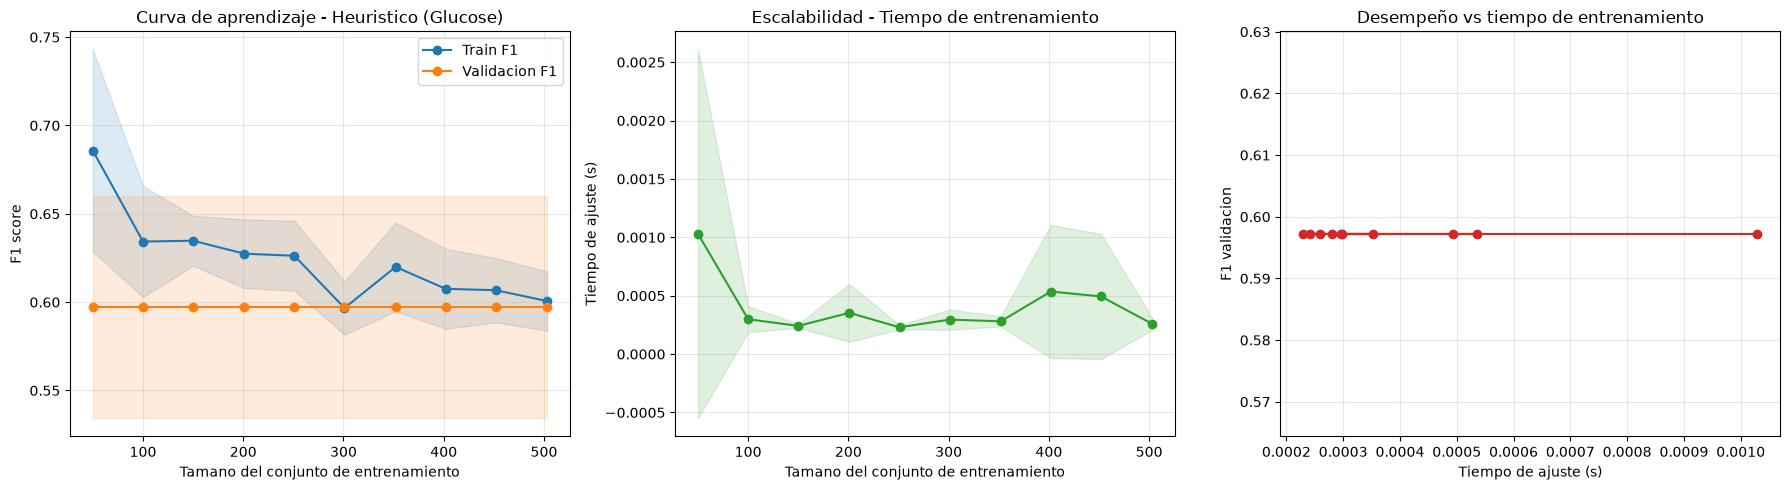

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de aprendizaje
axes[0].plot(train_sizes_abs, train_scores_media, "o-", color="tab:blue", label="Train F1")
axes[0].fill_between(
    train_sizes_abs,
    train_scores_media - train_scores_std,
    train_scores_media + train_scores_std,
    alpha=0.15,
    color="tab:blue",
)
axes[0].plot(train_sizes_abs, val_scores_media, "o-", color="tab:orange", label="Validacion F1")
axes[0].fill_between(
    train_sizes_abs,
    val_scores_media - val_scores_std,
    val_scores_media + val_scores_std,
    alpha=0.15,
    color="tab:orange",
)
axes[0].set_xlabel("Tamano del conjunto de entrenamiento")
axes[0].set_ylabel("F1 score")
axes[0].set_title("Curva de aprendizaje - Heuristico (Glucose)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Escalabilidad: tiempo de ajuste vs tamano de datos
axes[1].plot(train_sizes_abs, fit_times_media, "o-", color="tab:green")
axes[1].fill_between(
    train_sizes_abs,
    fit_times_media - fit_times_std,
    fit_times_media + fit_times_std,
    alpha=0.15,
    color="tab:green",
)
axes[1].set_xlabel("Tamano del conjunto de entrenamiento")
axes[1].set_ylabel("Tiempo de ajuste (s)")
axes[1].set_title("Escalabilidad - Tiempo de entrenamiento")
axes[1].grid(alpha=0.3)

# 3. Desempeño vs tiempo de ajuste
axes[2].plot(fit_times_media, val_scores_media, "o-", color="tab:red")
axes[2].set_xlabel("Tiempo de ajuste (s)")
axes[2].set_ylabel("F1 validacion")
axes[2].set_title("Desempeño vs tiempo de entrenamiento")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../../data/08_reporting/baseline_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Validación cruzada liviana (KFold=5, sobre train)

In [17]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ["accuracy", "precision", "recall", "f1"]

resultados_cv = []
for nombre, modelo in modelos.items():
    scores = cross_validate(modelo, X_train, y_train, cv=kfold, scoring=metricas_cv)
    fila = {"modelo": nombre}
    for metrica in metricas_cv:
        fila[f"{metrica}_media"] = scores[f"test_{metrica}"].mean()
        fila[f"{metrica}_std"] = scores[f"test_{metrica}"].std()
    resultados_cv.append(fila)

tabla_cv = pd.DataFrame(resultados_cv).set_index("modelo").round(3)
tabla_cv

/home/camila/Diabetes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/camila/Diabetes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/camila/Diabetes/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cami

,accuracy_media,accuracy_std,precision_media,precision_std,recall_media,recall_std,f1_media,f1_std
modelo,,,,,,,,
Trivial (DummyClassifier),0.647,0.027,0.000,0.000,0.000,0.000,0.000,0.000
Heuristico (Glucose),0.709,0.061,0.589,0.076,0.623,0.038,0.605,0.056
Heuristico (Glucose + BMI),0.555,0.025,0.436,0.022,0.905,0.031,0.589,0.025


In [18]:
MODEL_OUTPUT_DIR = Path("../../data/07_model_output")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tabla_resultados.to_csv(MODEL_OUTPUT_DIR / "baseline_metrics_test.csv")
tabla_cv.to_csv(MODEL_OUTPUT_DIR / "baseline_metrics_cv.csv")

In [ ]:
MODEL_OUTPUT_DIR = Path("../../data/07_model_output")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tabla_resultados.to_csv(MODEL_OUTPUT_DIR / "baseline_metrics_test.csv")
tabla_cv.to_csv(MODEL_OUTPUT_DIR / "baseline_metrics_cv.csv")

MODELS_DIR = Path("../../data/06_models")
joblib.dump(modelos["Heuristico (Glucose)"], MODELS_DIR / "modelo_baseline_heuristico.joblib")

['../../data/06_models/modelo_baseline_heuristico.joblib']

## Hallazgos - Modelo Baseline

### Comparación en test
| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Trivial (DummyClassifier) | 0.646 | 0.000 | 0.000 | 0.000 |
| Heurístico (Glucose) | 0.797 | 0.731 | 0.679 | 0.704 |
| Heurístico (Glucose + BMI) | 0.589 | 0.459 | 0.893 | 0.606 |

- El baseline trivial confirma: predecir siempre "no diabetes" da 64.6% de
  accuracy (coincide con la proporción de la clase mayoritaria en test), pero con
  recall y precision en 0 — no identifica ningún caso positivo, inútil como
  predictor real.
- La regla heurística de una sola variable (Glucose > 127) es netamente superior al
  trivial en las 4 métricas, y razonablemente balanceada: identifica el 67.9% de
  los casos positivos reales (recall) con 73.1% de precisión.
- La regla combinada (Glucose > 127 O BMI > 30) sacrifica demasiado: aunque su
  recall sube a 89.3% (detecta casi todos los positivos), su precisión cae a 45.9%
  (más de la mitad de sus predicciones positivas son falsas alarmas) y su accuracy
  (58.9%) queda **por debajo del baseline trivial** — clasifica peor en general que
  simplemente predecir "no" siempre, a pesar de capturar más positivos. No es un
  buen candidato de baseline.

### Validación cruzada (KFold=5, train)
- Los resultados de CV son consistentemente más bajos que los de test para el
  heurístico simple (accuracy 70.9% CV vs. 79.7% test; recall 62.3% CV vs. 67.9%
  test). Esto es esperable: el modelo es una regla fija que no "aprende" de los
  datos, así que el CV solo mide qué tan estable es la regla entre distintos
  subconjuntos — la diferencia con test refleja variabilidad muestral propia de un
  dataset pequeño (787 filas), no overfitting.
- El mismo trade-off se repite en el heurístico combinado (55.5% accuracy CV, 90.5%
  recall CV).

### Decisión: modelo baseline oficial
Se elige el **Heurístico (Glucose > 127)** como modelo baseline oficial para las
Tareas 6 y 7, por equilibrar mejor las 4 métricas sin caer por debajo del trivial.
El recall de 67.9% (test) / 62.3% (CV) queda como el piso que los modelos de la
Tarea 6 deben superar, idealmente sin sacrificar tanto la precisión como lo hace la
regla combinada.

### Interpretación de la Learning Curve y escalabilidad

**F1 de validación completamente plano (0.597 en los 10 tamaños evaluados).**
Esto es coherente con la naturaleza del modelo: `ModeloHeuristico.predict()` no
depende de los datos de entrenamiento (aplica siempre la regla fija
`Glucose > 127`), por lo que el desempeño en el fold de validación no cambia
sin importar cuántas filas de entrenamiento se usen. El modelo no "aprende"
en el sentido estadístico, así que no puede haber overfitting ni mejora
progresiva.

**F1 de train varía (0.686 → ~0.60) y luego se estabiliza.** Con muestras
pequeñas (50 filas) el subconjunto de entrenamiento puede tener por azar una
proporción distinta de positivos, lo que infla o reduce el F1 calculado sobre
esa misma muestra. A partir de ~150-200 filas el valor se estabiliza cerca de
0.60-0.61, más cercano al F1 de validación. Esta es varianza por tamaño de
muestra, no aprendizaje real.

**Nota sobre la diferencia con el F1 de test reportado antes (0.704):** el
valor de esta curva (0.597) proviene de la validación cruzada interna sobre
`X_train`/`y_train` (5 folds), mientras que el 0.704 se calculó una sola vez
sobre `X_test` (el conjunto de prueba separado). Ambos son válidos; miden
cosas distintas (variabilidad promedio en CV vs. desempeño puntual en el
conjunto de prueba final) y la diferencia es esperable con un dataset
pequeño.

**Tiempo de ajuste (fit_time) es prácticamente constante y del orden de
microsegundos (~0.0002-0.001 s), sin tendencia creciente con el tamaño de
los datos.** Esto es consistente con que `fit()` no realiza ningún cómputo
sobre los datos: solo fija `self.classes_`. Confirma que el modelo baseline
es computacionalmente trivial y escala perfectamente (no hay costo de
entrenamiento que crezca con el volumen de datos).

**Conclusión:** la curva plana no es un error ni una limitación del análisis;
es el comportamiento correcto y esperado para un modelo basado en una regla
fija. Sirve como referencia de comparación: en la Tarea 6 se espera que los
modelos entrenados (Random Forest, KNN, Regresión Logística) sí muestren
curvas de aprendizaje con dependencia del tamaño de los datos y tiempos de
ajuste crecientes, a diferencia de este baseline.